# **CREDIT CARD PROJECT**

### **Ingest data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid", {"axes.facecolor": ".9"})
sns.set_context("paper")

In [2]:
df = pd.read_excel("../data/credit_card.xls", sheet_name="Data")
df_copy = df.copy()
df_copy.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [3]:
# check columns and data types
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  object
 20  X20   

In [4]:
# names for columns: 

# REPAYMENT STATUS
# X6--> PAY_0 month 6 : rep_status_mth_6
# X7--> PAY_2 month 5 : rep_status_mth_5
# X8--> PAY_3 month 4 : rep_status_mth_4
# X9--> PAY_4 month 3 : rep_status_mth_3
# X10--> PAY_5 month 2 : rep_status_mth_2
# X11--> PAY_6 month 1 : rep_status_mth_1

# BILL STATUS
# X12--> bill_amt_mth_6
# X13--> bill_amt_mth_5
# X14--> bill_amt_mth_4
# X15--> bill_amt_mth_3
# X16--> bill_amt_mth_2
# X17--> bill_amt_mth_1

# AMOUNT OF PREVIOUS PAYMENT
# X18--> pmt_amt_mth_6
# X19--> pmt_amt_mth_5
# X20--> pmt_amt_mth_4
# X21--> pmt_amt_mth_3
# X22--> pmt_amt_mth_2
# X23--> pmt_amt_mth_1
custom_col_names = ["limit", "gender", "edu", "marital_status", "age",
                    "rep_status_mth_6", "rep_status_mth_5", "rep_status_mth_4", 
                    "rep_status_mth_3", "rep_status_mth_2", "rep_status_mth_1",

                    "bill_amt_mth_6", "bill_amt_mth_5", "bill_amt_mth_4", 
                    "bill_amt_mth_3", "bill_amt_mth_2", "bill_amt_mth_1",

                    "pmt_amt_mth_6", "pmt_amt_mth_5", "pmt_amt_mth_4",
                    "pmt_amt_mth_3", "pmt_amt_mth_2", "pmt_amt_mth_1",
                    "target"]

In [5]:
# change column names to names on first row
df_copy.columns = df_copy.iloc[0].values # first row becomes the columns
df_copy = df_copy.iloc[1:].reset_index(drop=True).drop('ID', axis=1) #drop ID column. not useful
df_copy.columns = custom_col_names #replace columns with custom names
df_copy.head(3)

,limit,gender,edu,marital_status,age,rep_status_mth_6,rep_status_mth_5,rep_status_mth_4,rep_status_mth_3,rep_status_mth_2,...,bill_amt_mth_3,bill_amt_mth_2,bill_amt_mth_1,pmt_amt_mth_6,pmt_amt_mth_5,pmt_amt_mth_4,pmt_amt_mth_3,pmt_amt_mth_2,pmt_amt_mth_1,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## **EXPLORE**

##### **1. check data types**


In [6]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   limit             30000 non-null  object
 1   gender            30000 non-null  object
 2   edu               30000 non-null  object
 3   marital_status    30000 non-null  object
 4   age               30000 non-null  object
 5   rep_status_mth_6  30000 non-null  object
 6   rep_status_mth_5  30000 non-null  object
 7   rep_status_mth_4  30000 non-null  object
 8   rep_status_mth_3  30000 non-null  object
 9   rep_status_mth_2  30000 non-null  object
 10  rep_status_mth_1  30000 non-null  object
 11  bill_amt_mth_6    30000 non-null  object
 12  bill_amt_mth_5    30000 non-null  object
 13  bill_amt_mth_4    30000 non-null  object
 14  bill_amt_mth_3    30000 non-null  object
 15  bill_amt_mth_2    30000 non-null  object
 16  bill_amt_mth_1    30000 non-null  object
 17  pmt_amt_mth_

In [7]:
# no null values. but confirm
df_copy.isna().sum().sum()

# no null values

np.int64(0)

> All datatypes are objects. even the numerical ones. 

> Ideally, all columns should be int, per data docs.

In [8]:
# per data docs all the vales are int.
df_copy = df_copy.astype('int') #change dtype to int for all variables
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   limit             30000 non-null  int64
 1   gender            30000 non-null  int64
 2   edu               30000 non-null  int64
 3   marital_status    30000 non-null  int64
 4   age               30000 non-null  int64
 5   rep_status_mth_6  30000 non-null  int64
 6   rep_status_mth_5  30000 non-null  int64
 7   rep_status_mth_4  30000 non-null  int64
 8   rep_status_mth_3  30000 non-null  int64
 9   rep_status_mth_2  30000 non-null  int64
 10  rep_status_mth_1  30000 non-null  int64
 11  bill_amt_mth_6    30000 non-null  int64
 12  bill_amt_mth_5    30000 non-null  int64
 13  bill_amt_mth_4    30000 non-null  int64
 14  bill_amt_mth_3    30000 non-null  int64
 15  bill_amt_mth_2    30000 non-null  int64
 16  bill_amt_mth_1    30000 non-null  int64
 17  pmt_amt_mth_6     30000 non-nul

##### **2. summary stats**


In [9]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
limit,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
gender,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
edu,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
marital_status,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
rep_status_mth_6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
rep_status_mth_5,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
rep_status_mth_4,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
rep_status_mth_3,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
rep_status_mth_2,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [10]:
# repayment status encodings. 
# minimum value is -2 and maximum is 8

# -2: no consumption
# -1: paid duly
# 0: used revolving credit
# 1: payment delayed by a month
# 2: payment delayed by 2 months....

> Education: has min value of 0 and max of 6. But official docs is from 1-4

> Marital status is from 1-3 which is alignment with official data docs.

> Age is from 21 to 79.

> Repayment status has been described above

> Limit Bal has a max of 1m, min of 10,000 while mean is 167,000. This suggests possible outliers.

##### **3. check categories within appropriate variables**


In [11]:
# check categories in GENDER col.
df_copy['gender'].value_counts()

# 1 for Male
# 2 for Female

gender
2    18112
1    11888
Name: count, dtype: int64

In [12]:
# check categories in EDUCATION col.
print(df_copy['edu'].value_counts())

# 1: Graduate School
# 2: Undergrad/University
# 3: High School
# 4: Others 

# use the categories above
edu_cat = [1,2,3]
#df_copy['edu'] = df_copy['edu'].apply(lambda x: x if x in edu_cat else 4)
print(df_copy['edu'].apply(lambda x: x if x in edu_cat else 4).value_counts())

edu
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
edu
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


In [13]:
# check categories in MARITAL STATUS col.
print(df_copy['marital_status'].value_counts())

# 1: Married
# 2: Single
# 3: Others

# use the categories above
marital_cat = [1,2]
#df_copy['marital_status'] = df_copy['marital_status'].apply(lambda x: x if x in marital_cat else 3)
print(df_copy['marital_status'].apply(lambda x: x if x in marital_cat else 3).value_counts())

marital_status
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
marital_status
2    15964
1    13659
3      377
Name: count, dtype: int64


In [14]:
df_copy[["rep_status_mth_6"]].value_counts()

# repayment status encodings. 
# minimum value is -2 and maximum is 8

# -2: no consumption
# -1: paid duly
# 0: used revolving credit
# 1: payment delayed by a month
# 2: payment delayed by 2 months....

rep_status_mth_6
 0                  14737
-1                   5686
 1                   3688
-2                   2759
 2                   2667
 3                    322
 4                     76
 5                     26
 8                     19
 6                     11
 7                      9
Name: count, dtype: int64

#### **4. MORE EDA**

##### **i. class distribution**

In [15]:
# distribution of defaulters vs non-defaulters
df_copy.target.value_counts()

target
0    23364
1     6636
Name: count, dtype: int64

In [16]:
print(f"Percentage of defaulters in dataset is: {df_copy.target.mean()*100}%")

Percentage of defaulters in dataset is: 22.12%


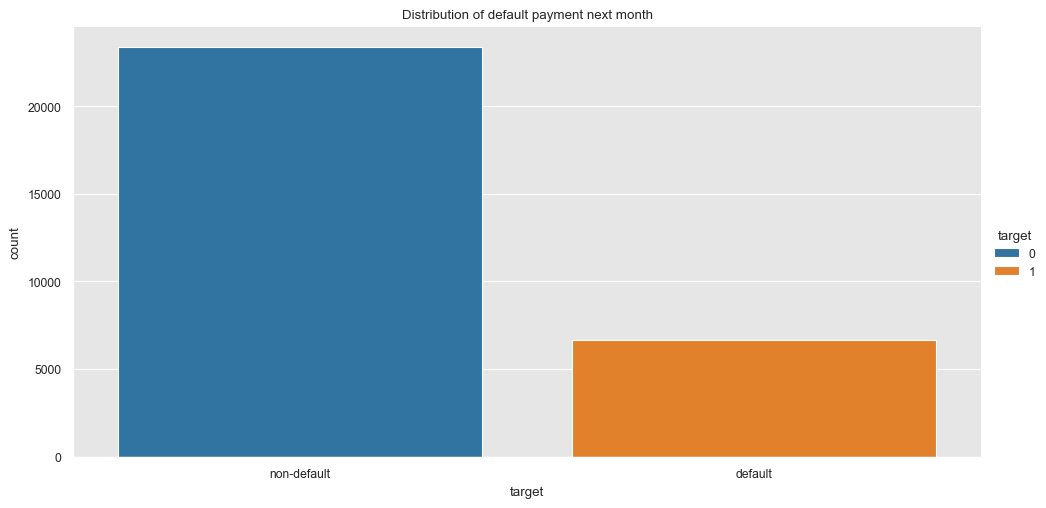

In [17]:
sns.catplot(data=df_copy, kind='count', x='target', hue='target', aspect=2, estimator='count')
plt.title('Distribution of default payment next month')
plt.xticks([0,1], ["non-default", "default"])
plt.show()

> The plot above shows a wide class imbalance with the target variable. Defaulters are about 22% of the dataset

##### **ii. Default Rate by Repayments**

In [18]:
df_copy_def_rate_chart = df_copy.copy()
df_copy_def_rate_chart['rep_status_mth_6_converted'] = df_copy_def_rate_chart['rep_status_mth_6'].apply(
                                                                    lambda x:"no_consump" if x==-2 
                                                                    else "paid_duly" if x==-1 
                                                                    else "revolve_cred" if x==0
                                                                    else "1_mnth_late" if x==1
                                                                    else "2_mnths_late" if x==2
                                                                    else "3+_mnths_late")
def_by_repayment = df_copy_def_rate_chart.groupby(['rep_status_mth_6_converted'])['target'].mean().sort_values()
def_by_repayment = round(def_by_repayment, 4)*100

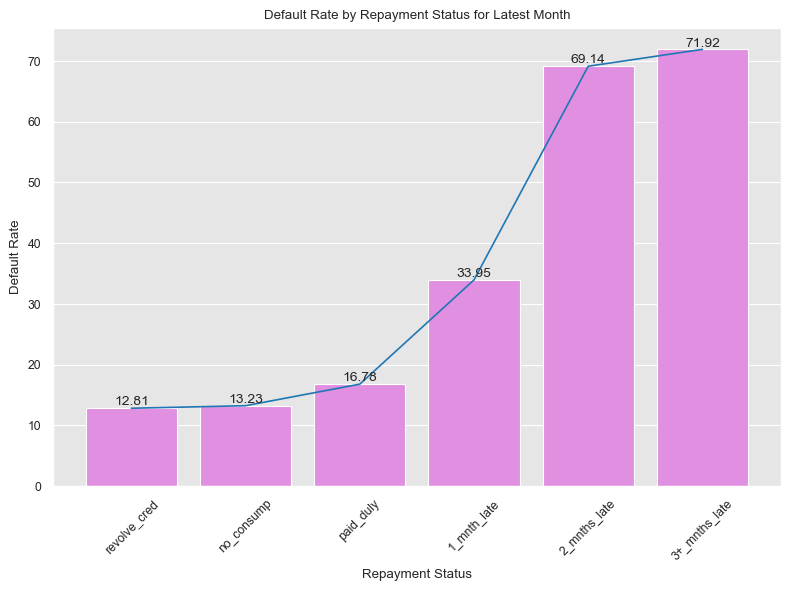

In [19]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=def_by_repayment.index, y=def_by_repayment.values, color='violet')
ax.bar_label(ax.containers[0], fontsize=10)
sns.lineplot(x=def_by_repayment.index, y=def_by_repayment.values)
plt.title('Default Rate by Repayment Status for Latest Month')
plt.xticks(rotation=45)
plt.xlabel("Repayment Status")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

> Insight: Default rate increases with delays in monthly payments.

##### **iii. Default Rate by Pay Streak**

In [20]:
df_copy_def_rate_chart.iloc[:,5:11].head(3)

,rep_status_mth_6,rep_status_mth_5,rep_status_mth_4,rep_status_mth_3,rep_status_mth_2,rep_status_mth_1
0,2,2,-1,-1,-2,-2
1,-1,2,0,0,0,2
2,0,0,0,0,0,0


In [21]:
# get number of times customer made late payments
df_copy_def_rate_chart['pay_streak'] = (df_copy_def_rate_chart.iloc[:,5:11]>0).sum(axis=1)
df_copy_def_rate_chart.head(3)

,limit,gender,edu,marital_status,age,rep_status_mth_6,rep_status_mth_5,rep_status_mth_4,rep_status_mth_3,rep_status_mth_2,...,bill_amt_mth_1,pmt_amt_mth_6,pmt_amt_mth_5,pmt_amt_mth_4,pmt_amt_mth_3,pmt_amt_mth_2,pmt_amt_mth_1,target,rep_status_mth_6_converted,pay_streak
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,2_mnths_late,2
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,paid_duly,2
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,revolve_cred,0


In [22]:
def_by_pay_streak = df_copy_def_rate_chart.groupby('pay_streak')['target'].mean().sort_values()
def_by_pay_streak = round(def_by_pay_streak, 4)*100

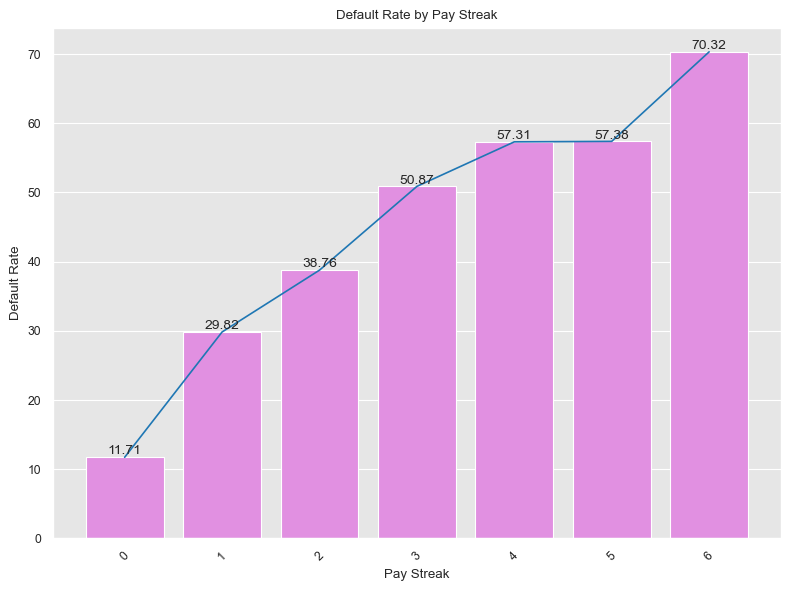

In [23]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=def_by_pay_streak.index, y=def_by_pay_streak.values,color='violet')
ax.bar_label(ax.containers[0], fontsize=10)
sns.lineplot(x=def_by_pay_streak.index, y=def_by_pay_streak.values)
plt.title('Default Rate by Pay Streak')
plt.xticks(rotation=45)
plt.xlabel("Pay Streak")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

##### **iv. Limit Balance Distribution by Default**

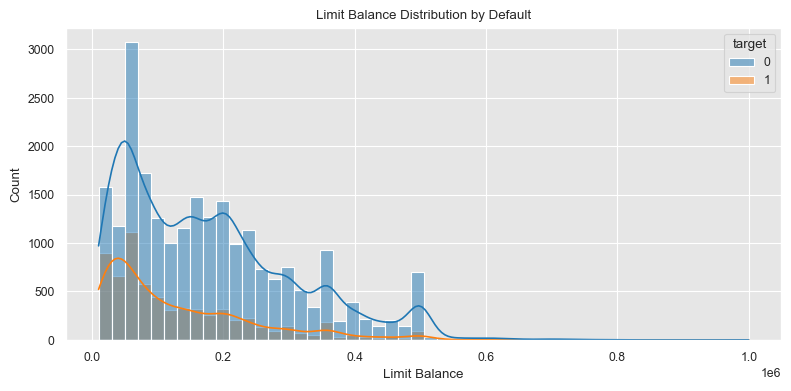

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_copy_def_rate_chart, x='limit', hue='target', kde=True, bins=50)
plt.title('Limit Balance Distribution by Default')
plt.xlabel("Limit Balance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

> The Limit balance feature is right skewed with most defaults as well as non defaulters having lower credit limits 

##### **v. Bill Amount Trend**

In [25]:
non_def_df = df_copy_def_rate_chart[df_copy_def_rate_chart['target']==0]
non_def_bill_amts = non_def_df.loc[:,"bill_amt_mth_6":"bill_amt_mth_1"].mean().sort_values()

def_df = df_copy_def_rate_chart[df_copy_def_rate_chart['target']==1]
def_bill_amts = def_df.loc[:,"bill_amt_mth_6":"bill_amt_mth_1"].mean().sort_values()

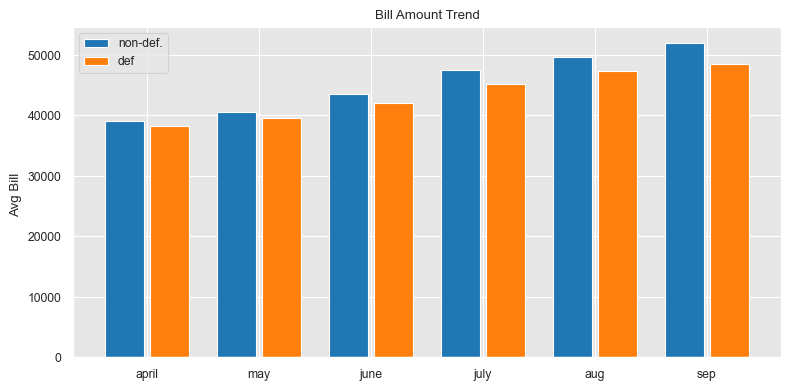

In [26]:
months = ['april', 'may', 'june', 'july', 'aug', 'sep']
plt.figure(figsize=(8, 4))
plt.bar(np.arange(1, 7)-0.2, non_def_bill_amts.values, width=0.35, label="non-def.")
plt.bar(np.arange(1, 7)+0.2, def_bill_amts.values, width=0.35, label='def')
plt.xticks(np.arange(1, 7), months)
plt.title('Bill Amount Trend')
plt.ylabel("Avg Bill ")
plt.legend()
plt.tight_layout()
plt.show()

##### **vi. Payment Ratio by Default**

In [27]:
# ratio = payment/bill
# be mindful of division by zero as well as -1 values. if you add 1 to -1 it equals 0, then this becomes div by zero again
def correcting_zero_div(row):
    if row['bill_amt_mth_6']==0:
        return row['pmt_amt_mth_6']/(row['bill_amt_mth_6']+1)
    else:
        return row['pmt_amt_mth_6']/row['bill_amt_mth_6']
    
df_copy_def_rate_chart['pmt_ratio'] = df_copy_def_rate_chart.apply(correcting_zero_div, axis=1)

In [28]:
df_copy_def_rate_chart['pmt_ratio'].describe().T

count     30000.000000
mean         92.525518
std        2699.592189
min      -35436.000000
25%           0.034330
50%           0.055521
75%           0.262302
max      298887.000000
Name: pmt_ratio, dtype: float64

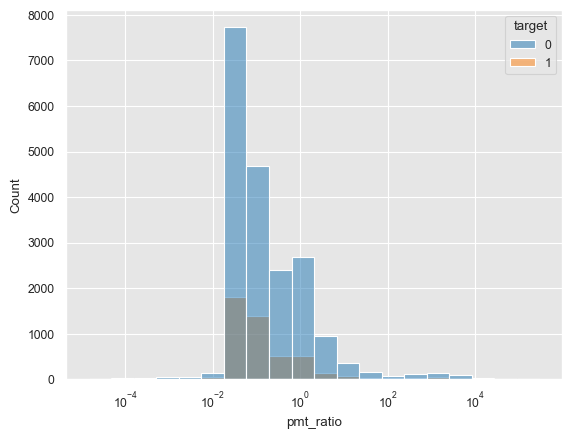

In [29]:
sns.histplot(data=df_copy_def_rate_chart, x='pmt_ratio', 
             log_scale=True, hue='target', bins=20)
plt.show()

#### **Demographic breakdowns**

##### **vii. Gender**

In [30]:
print("Count of gender")
df_copy['gender'].value_counts()


Count of gender


gender
2    18112
1    11888
Name: count, dtype: int64

In [31]:
print("Number of people in a gender per target")
print(f"{pd.crosstab(df_copy['target'], df_copy['gender'])}\n")

print("Percentage of gender per target")
print(pd.crosstab(df_copy['target'], df_copy['gender'], normalize='index'))

Number of people in a gender per target
gender     1      2
target             
0       9015  14349
1       2873   3763

Percentage of gender per target
gender         1         2
target                    
0       0.385850  0.614150
1       0.432942  0.567058


> there are more females than males in the dataset.

> females are more than males in either defaulters or non-defaulters.

##### **viii. education**

In [32]:
df_copy['edu'].value_counts()

edu
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [33]:
df_copy.edu.value_counts()

edu
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

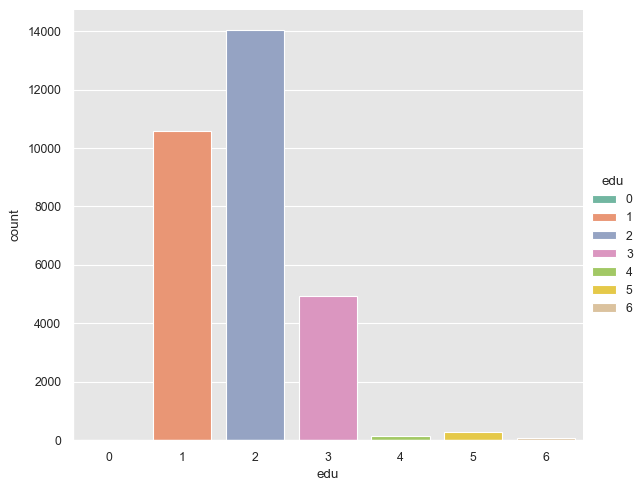

In [34]:
g=sns.catplot(data=df_copy, x='edu', kind='count', 
            hue='edu', estimator='mean', palette='Set2', aspect=1.2)
#g.set_axis_labels("Education", "Count")
#g.set_xticklabels(["graduate", "university", "high_sch", "others"])
g.set_titles("{col_name} {col_var}")
plt.show()

> Most credit card owners were bachelor and graduate degree holders.

> Customers with bachelors degree are higher than the other categories, with the next highest being graduate degrees. A similar trend is also present with the distribution across each target value.

> The other categories have low number of customers and behave the same. I will merge them to become 'other'

##### **ix. marital status**

In [35]:
df_copy['marital_status'].value_counts()

marital_status
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

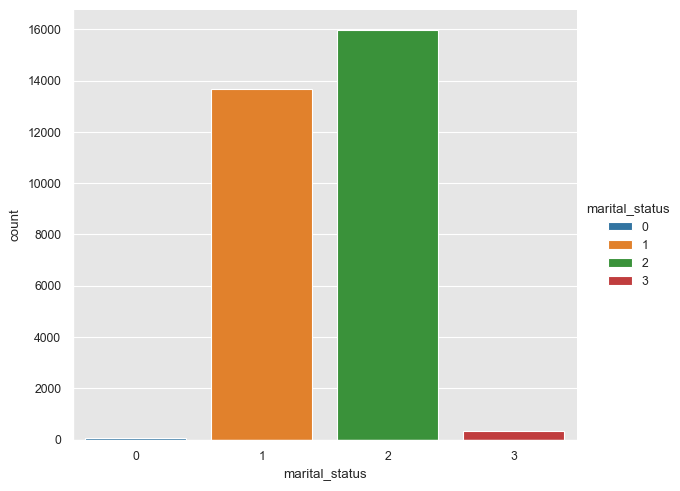

In [36]:
g=sns.catplot(data=df_copy, x='marital_status', kind='count', 
            hue='marital_status', estimator='mean', palette='tab10', aspect=1.2)
#g.set_axis_labels("Marital Status", "Count")
#g.set_xticklabels(["married", "single", "others"])
g.set_titles("{col_name} {col_var}")
plt.show()

> For defaulters, there is a similar number of married and single people who defaulted.

> 0 and 3 will be merged to become 'other'

##### **x. age**

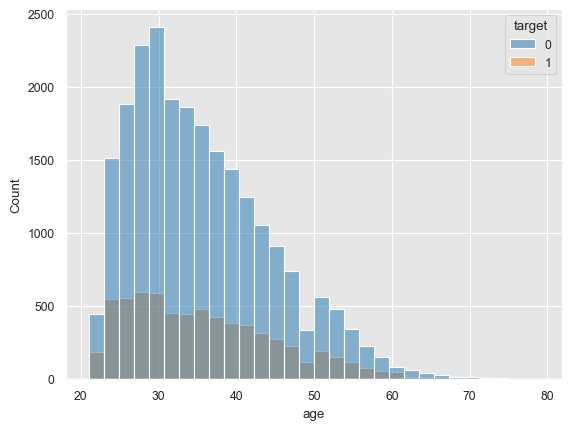

In [37]:
sns.histplot(data=df_copy, x='age', hue='target', bins=30)
plt.show()

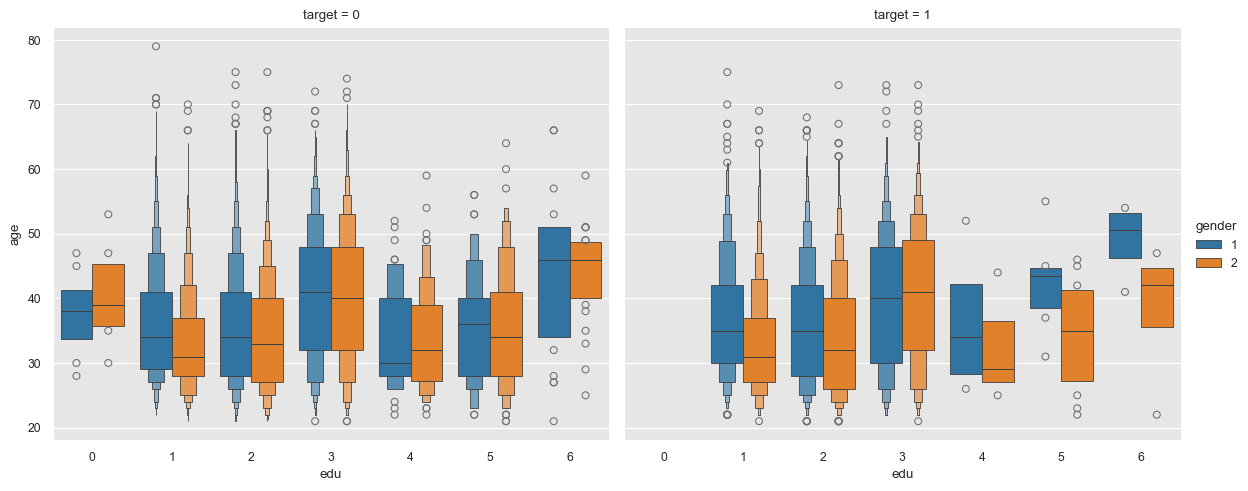

In [38]:
# distribution of age
sns.catplot(data=df_copy, x='edu', y='age', hue='gender',
            kind='boxen', palette='tab10', aspect=1.2, col='target')
plt.show()

##### **xi. Correlation**

In [39]:
corr = df_copy.corr()
corr_with_target = corr.loc[:,"target"]

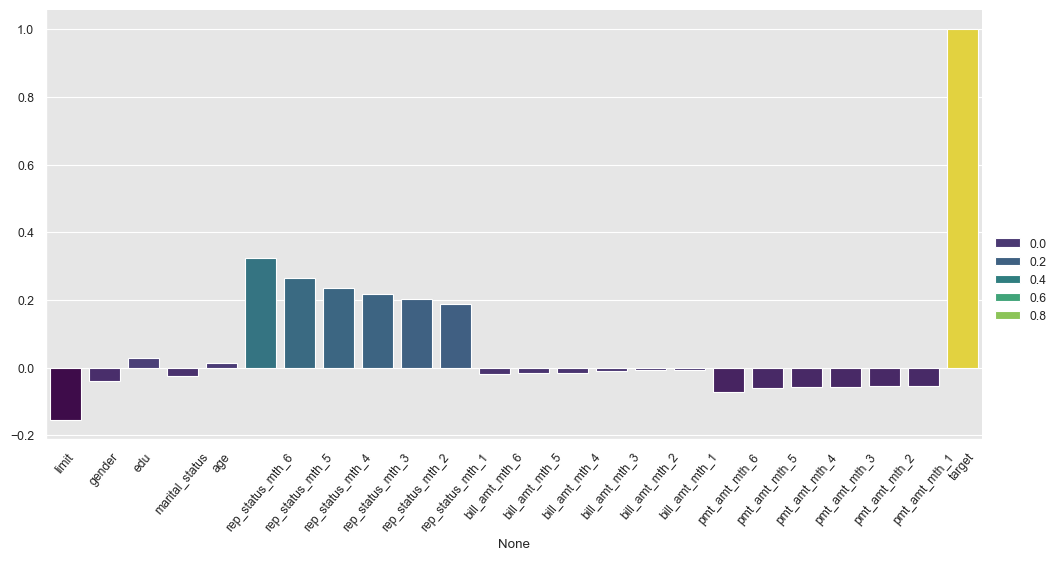

In [40]:
sns.catplot(x=corr_with_target.index, y=corr_with_target.values, hue=corr_with_target.values, 
            kind='bar', aspect=2, palette='viridis')
#plt.figure(figsize=(15,12))
plt.xticks(rotation=50)
plt.show()

##### **xii. Utilisation rate by default**

In [41]:
df_copy['utilisation_rate'] = df_copy['bill_amt_mth_6']/df_copy['limit']

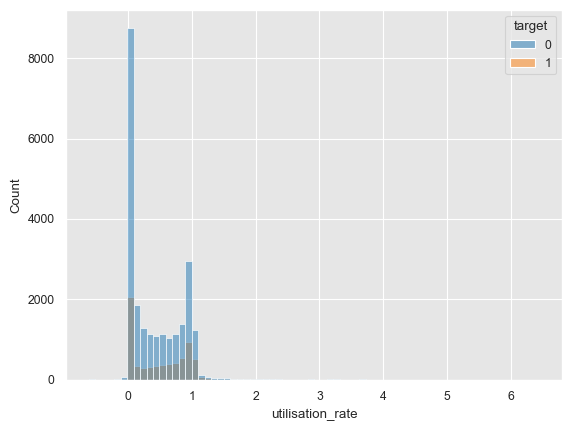

In [42]:
sns.histplot(data=df_copy, x ='utilisation_rate', hue='target', bins=70)
plt.show()

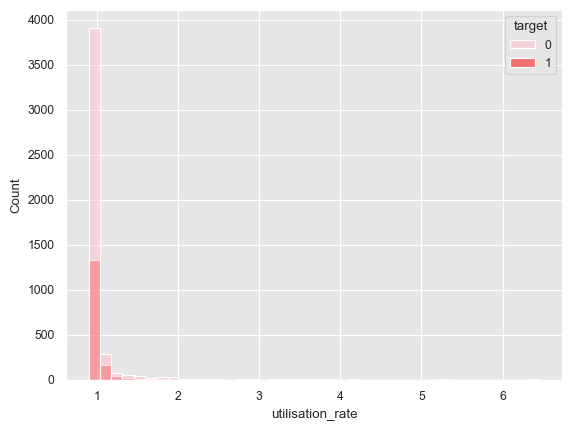

In [43]:
check_util = df_copy[df_copy['utilisation_rate']>0.9]
sns.histplot(data=check_util, x ='utilisation_rate', hue='target', palette=['pink', 'red'], bins=40)
plt.show()

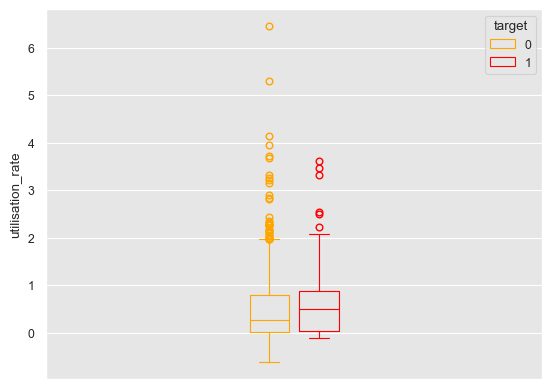

In [44]:
sns.boxplot(data=df_copy, y='utilisation_rate', 
            hue='target', palette=['orange', 'red'], linewidth=0.8, width=.2, gap=.2, fill=False)
plt.show()

## **LOAD DATA & DATA SPLIT**

In [45]:
# load dataset
def load_dataset(data_path, frac=None, read_excel=None, read_csv=None):
    if read_excel:
        df = pd.read_excel(data_path)
    if read_csv:
        df = pd.read_csv(data_path)

    df = df.sample(frac=frac) if frac else df
    return df

In [46]:
def categorize_features(df):
    df = df.astype('int') #change to integers

    # education
    # 1: Graduate School
    # 2: Undergrad/University
    # 3: High School
    # 4: Others 
    # use the categories above
    edu_cat = [1,2,3]
    df['edu'] = df['edu'].apply(lambda x: x if x in edu_cat else 4)

    # marital status
    # 1: Married
    # 2: Single
    # 3: Others
    # use the categories above
    marital_cat = [1,2]
    df['marital_status'] = df['marital_status'].apply(lambda x: x if x in marital_cat else 3)
    return df 

In [47]:
#clean columns function
def clean_cols(df):
    # create dataset with readable column names
    custom_col_names = ["limit", "gender", "edu", "marital_status", "age",
                    "rep_status_mth_6", "rep_status_mth_5", "rep_status_mth_4", 
                    "rep_status_mth_3", "rep_status_mth_2", "rep_status_mth_1",

                    "bill_amt_mth_6", "bill_amt_mth_5", "bill_amt_mth_4", 
                    "bill_amt_mth_3", "bill_amt_mth_2", "bill_amt_mth_1",

                    "pmt_amt_mth_6", "pmt_amt_mth_5", "pmt_amt_mth_4",
                    "pmt_amt_mth_3", "pmt_amt_mth_2", "pmt_amt_mth_1",
                    "target"]

    # change column names to names on first row
    df.columns = df.iloc[0].values # first row becomes the columns
    df = df.iloc[1:].reset_index(drop=True).drop('ID', axis=1) #drop ID column. not useful
    df.columns = custom_col_names #replace columns with custom names

    df = categorize_features(df)
    return df



In [48]:
from sklearn.model_selection import train_test_split

In [49]:
# split dataset function
def split_dataset(df, test_size=0.2, random_state=42, save_dataset=None, path_to_save=None):
    train_df, test_df = train_test_split(df, test_size=test_size, stratify=df['target'], random_state=random_state)
    if save_dataset:
        train_df.to_csv(f"{path_to_save}/train_set.csv", index=False)
        test_df.to_csv(f"{path_to_save}/test_set.csv", index=False)
    return train_df, test_df

In [50]:
# 1. load dataset
data_path = "../data/credit_card.xls"
df = load_dataset(data_path=data_path, read_excel=True)

#2. # clean columns and properly categorize columns
df = clean_cols(df)

#3. split and save dataset
path_to_save = "../data/split"
train_df, test_df = split_dataset(df=df, save_dataset=True, path_to_save=path_to_save)
val_df, test_df = split_dataset(df=test_df, test_size=0.5)

In [51]:
class TargetEncoderDecoder:
    def __init__(self):
        self.targets = sorted(["non-default", "default"], reverse=True)
        self.index_to_class = {idx:class_name_ for idx, class_name_ in enumerate(self.targets)}
        self.class_to_index = {class_name_: idx for idx, class_name_ in self.index_to_class.items()}


In [52]:
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [53]:
#### create features
class FeatureEngineering(TransformerMixin, BaseEstimator):
    def fit(self, X):
        return self
    
    def correcting_zero_div(self, row):
        if row['bill_amt_mth_6']==0:
            return row['pmt_amt_mth_6']/(row['bill_amt_mth_6']+1)
        else:
            return row['pmt_amt_mth_6']/row['bill_amt_mth_6']

    def transform(self, X, y=None):
        df = X.copy()

        #pay streak
        df['pay_streak'] = (df[['rep_status_mth_6', 'rep_status_mth_5', 'rep_status_mth_4', 
                                'rep_status_mth_3', 'rep_status_mth_2', 'rep_status_mth_1']]>0).sum(axis=1)
        
        #avg payment delay
        df['avg_payment_delay'] = (df[['rep_status_mth_6', 'rep_status_mth_5', 
                                       'rep_status_mth_4','rep_status_mth_3',
                                       'rep_status_mth_2', 'rep_status_mth_1']]).mean(axis=1)
        
        # utilization_rate. upper limit reduced to 1
        df['utilization_rate'] = np.clip(df['bill_amt_mth_6']/df['limit'], None, 1)

        # payment ratio
        pmt_ratio = df.apply(self.correcting_zero_div, axis=1)
        df['pmt_ratio'] = np.clip(pmt_ratio, None, 1)
        
        # bill trend
        df['bill_trend'] = df['bill_amt_mth_6'] - df['bill_amt_mth_1']

        # avg utlization rate
        avg_utilization_rate = (df[['bill_amt_mth_6', 'bill_amt_mth_5', 'bill_amt_mth_4', 
                                    'bill_amt_mth_3', 'bill_amt_mth_2', 
                                    'bill_amt_mth_1']]).sum(axis=1)/(6*df['limit'])
        df['avg_utilization'] = np.clip(avg_utilization_rate, None, 1)

        df['worst_pmt_delay']=np.max(df[['rep_status_mth_6', 'rep_status_mth_5', 
                                         'rep_status_mth_4', 'rep_status_mth_3',
                                         'rep_status_mth_2', 'rep_status_mth_1']], axis=1)

        #cols_to_drop = ['bill_amt_mth_5', 'bill_amt_mth_4', 'bill_amt_mth_3', 'bill_amt_mth_2', 'bill_amt_mth_1', 
        #                'pmt_amt_mth_5', 'pmt_amt_mth_4', 'pmt_amt_mth_3', 'pmt_amt_mth_2', 'pmt_amt_mth_1',
        #                ]
        #df = df.drop(cols_to_drop, axis=1)
        return df

### **a. NO FEATURE ENGINEERING MODELLING**

In [54]:
# no feature engineering
X_train_no_fe, y_train_no_fe = train_df.drop('target', axis=1), train_df['target']
X_val_no_fe, y_val_no_fe = val_df.drop('target', axis=1), val_df['target']
X_test_no_fe, y_test_no_fe = test_df.drop('target', axis=1), test_df['target']

In [55]:
# NO FEATURE ENGINEERING
cat_cols = ['edu', 'marital_status']
num_cols = X_train_no_fe.drop(cat_cols+['gender'], axis=1).columns
print(f'Categorical cols: {cat_cols}\n')
print(f'Numerical cols: {num_cols}')

Categorical cols: ['edu', 'marital_status']

Numerical cols: Index(['limit', 'age', 'rep_status_mth_6', 'rep_status_mth_5',
       'rep_status_mth_4', 'rep_status_mth_3', 'rep_status_mth_2',
       'rep_status_mth_1', 'bill_amt_mth_6', 'bill_amt_mth_5',
       'bill_amt_mth_4', 'bill_amt_mth_3', 'bill_amt_mth_2', 'bill_amt_mth_1',
       'pmt_amt_mth_6', 'pmt_amt_mth_5', 'pmt_amt_mth_4', 'pmt_amt_mth_3',
       'pmt_amt_mth_2', 'pmt_amt_mth_1'],
      dtype='object')


In [56]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             precision_recall_curve, precision_score, recall_score, 
                             ConfusionMatrixDisplay, f1_score)

In [57]:
# logistic regression
preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols),
                                  ("cat", OneHotEncoder(drop="first", handle_unknown='error'), cat_cols),
                                  ("gen", OneHotEncoder(drop='if_binary', handle_unknown='error'), ['gender'])])

cnt_def = np.sum(y_train_no_fe==1)
cnt_non_def = np.sum(y_train_no_fe==0)
scale_pos_weight = cnt_non_def/cnt_def

models = {"Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),
          "Random Forest": RandomForestClassifier(n_estimators=100 , max_depth=6,random_state=42, class_weight="balanced"),
          "XGBoost": XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.05, 
                                    max_depth=6,scale_pos_weight=scale_pos_weight)
          }

In [58]:
results_no_fe = {}
models_no_feature_eng = {}
for name, ml_model in models.items():
    if name=="Logistic Regression":
        log_model = Pipeline([("preprocessor", preprocessor),
                              ("model", ml_model)])
        log_model.fit(X_train_no_fe, y_train_no_fe)
        preds = log_model.predict(X_val_no_fe)
        probs = log_model.predict_proba(X_val_no_fe)[:,1]
        models_no_feature_eng[name] = log_model

    else:
        ml_model.fit(X_train_no_fe, y_train_no_fe)
        preds = ml_model.predict(X_val_no_fe)
        probs = ml_model.predict_proba(X_val_no_fe)[:,1]
        models_no_feature_eng[name] = ml_model

    results_no_fe[name] = {"roc_auc_score": round(roc_auc_score(y_val_no_fe, probs), 4),
                    "recall": round(recall_score(y_val_no_fe, preds), 4), 
                    "precision": round(precision_score(y_val_no_fe, preds), 4),
                    "f1_score": round(f1_score(y_val_no_fe, preds), 4)
                    }
    
results_df = pd.DataFrame(results_no_fe)

In [59]:
results_df.T.sort_values('roc_auc_score', ascending=False)

,roc_auc_score,recall,precision,f1_score
Random Forest,0.7882,0.5873,0.5200,0.5516
XGBoost,0.7862,0.6175,0.4952,0.5496
Logistic Regression,0.7297,0.6566,0.3882,0.4880


### **b. FEATURE ENGINEERING MODELLING**

In [60]:
# feature engineering

feature_engineering = FeatureEngineering()
train_df_fe = feature_engineering.fit_transform(train_df)
val_df_fe = feature_engineering.transform(val_df)
test_df_fe = feature_engineering.transform(test_df)

X_train_fe, y_train_fe = train_df_fe.drop('target', axis=1), train_df_fe['target']
X_val_fe, y_val_fe = val_df_fe.drop('target', axis=1), val_df_fe['target']
X_test_fe, y_test_fe = test_df_fe.drop('target', axis=1), test_df_fe['target']

In [61]:
# NO FEATURE ENGINEERING
cat_cols = ['edu', 'marital_status']
num_cols = X_train_fe.drop(cat_cols+['gender'], axis=1).columns
print(f'Categorical cols: {cat_cols}\n')
print(f'Numerical cols: {num_cols}')

Categorical cols: ['edu', 'marital_status']

Numerical cols: Index(['limit', 'age', 'rep_status_mth_6', 'rep_status_mth_5',
       'rep_status_mth_4', 'rep_status_mth_3', 'rep_status_mth_2',
       'rep_status_mth_1', 'bill_amt_mth_6', 'bill_amt_mth_5',
       'bill_amt_mth_4', 'bill_amt_mth_3', 'bill_amt_mth_2', 'bill_amt_mth_1',
       'pmt_amt_mth_6', 'pmt_amt_mth_5', 'pmt_amt_mth_4', 'pmt_amt_mth_3',
       'pmt_amt_mth_2', 'pmt_amt_mth_1', 'pay_streak', 'avg_payment_delay',
       'utilization_rate', 'pmt_ratio', 'bill_trend', 'avg_utilization',
       'worst_pmt_delay'],
      dtype='object')


In [ ]:
# logistic regression
preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols),
                                  ("cat", OneHotEncoder(drop="first", handle_unknown='error'), cat_cols),
                                  ("gen", OneHotEncoder(drop='if_binary', handle_unknown='error'), ['gender'])])

cnt_def = np.sum(y_train_fe==1)
cnt_non_def = np.sum(y_train_fe==0)
scale_pos_weight = cnt_non_def/cnt_def

models = {"Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),
          "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=6,random_state=42, class_weight="balanced"),
          "XGBoost": XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.05, 
                                    max_depth=6, scale_pos_weight=scale_pos_weight)}

In [134]:
results = {}
models_feature_eng = {}
for name, ml_model in models.items():
    if name=="Logistic Regression":
        log_model = Pipeline([("preprocessor", preprocessor),
                              ("model", ml_model)])
        log_model.fit(X_train_fe, y_train_fe)
        preds = log_model.predict(X_val_fe)
        probs = log_model.predict_proba(X_val_fe)[:,1]
        models_feature_eng[name] = log_model

    else:
        ml_model.fit(X_train_fe, y_train_fe)
        preds = ml_model.predict(X_val_fe)
        probs = ml_model.predict_proba(X_val_fe)[:,1]
        models_feature_eng[name] = ml_model

    results[name] = {"roc_auc_score": round(roc_auc_score(y_val_fe, probs), 4),
                    "recall": round(recall_score(y_val_fe, preds), 4), 
                    "precision": round(precision_score(y_val_fe, preds), 4),
                    "f1_score": round(f1_score(y_val_fe, preds), 4)
                    }
    
results_df_fe = pd.DataFrame(results)

In [147]:
results_df_fe_t = results_df_fe.T.reset_index(names=["model"])
results_df_fe_t

,model,roc_auc_score,recall,precision,f1_score
0,Logistic Regression,0.7630,0.6145,0.4569,0.5241
1,Random Forest,0.7854,0.6205,0.4719,0.5361
2,XGBoost,0.7836,0.6069,0.4708,0.5303


#### **EVALUATE**

In [66]:
# final model is random Forest with feature engineering
overall_metrics = {}

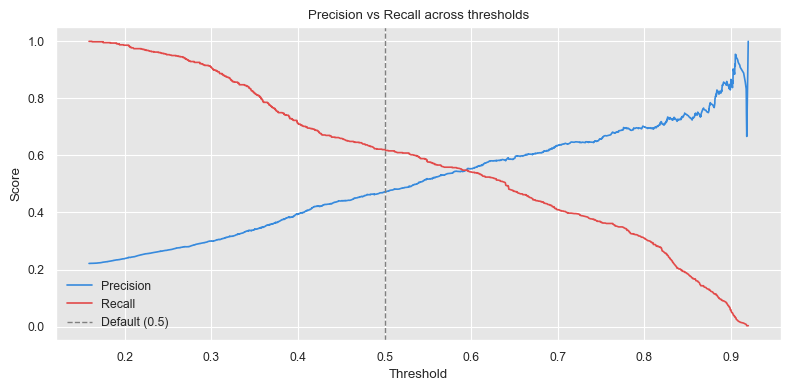

In [67]:
import matplotlib.pyplot as plt

probs = models_feature_eng['Random Forest'].predict_proba(X_val_fe)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val_fe, probs)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#378ADD')
plt.plot(thresholds, recalls[:-1],   label='Recall',    color='#E24B4A')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(frameon=False)
plt.title('Precision vs Recall across thresholds')
plt.tight_layout()
plt.show()

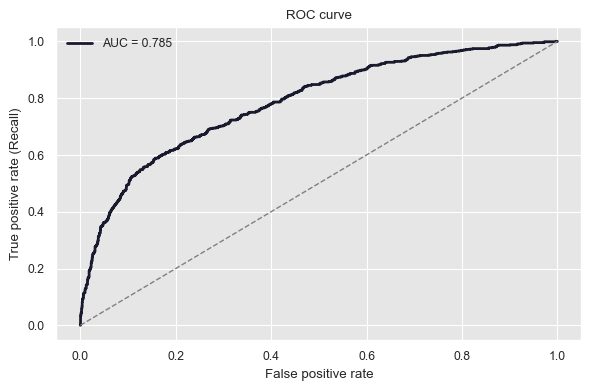

In [68]:
from sklearn.metrics import roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_val_fe, probs)
auc = roc_auc_score(y_val_fe, probs)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='#1A1A2E', linewidth=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], linestyle='--', color='gray', linewidth=1)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (Recall)')
plt.title('ROC curve')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [69]:
from sklearn.metrics import f1_score
import numpy as np

thresholds_to_try = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds_to_try:
    preds_t = (probs >= t).astype(int)
    scores.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_val_fe, preds_t, zero_division=0),
        'recall':    recall_score(y_val_fe, preds_t),
        'f1':        f1_score(y_val_fe, preds_t)
    })

scores_df = pd.DataFrame(scores)

# best by F1
best_f1_row = scores_df.loc[scores_df['f1'].idxmax()]
print(best_f1_row)

# best recall while keeping precision above 0.50
viable = scores_df[scores_df['precision'] >= 0.4]
best_recall_row = viable.loc[viable['recall'].idxmax()]
print(best_recall_row)

threshold    0.580000
precision    0.543319
recall       0.557229
f1           0.550186
Name: 48, dtype: float64
threshold    0.410000
precision    0.406469
recall       0.700301
f1           0.514381
Name: 31, dtype: float64


In [70]:
scores_df.head(60)

,threshold,precision,recall,f1
0,0.10,0.221333,1.000000,0.362445
1,0.11,0.221333,1.000000,0.362445
2,0.12,0.221333,1.000000,0.362445
3,0.13,0.221333,1.000000,0.362445
4,0.14,0.221333,1.000000,0.362445
5,0.15,0.221333,1.000000,0.362445
6,0.16,0.221629,1.000000,0.362842
7,0.17,0.223383,0.998494,0.365088
8,0.18,0.227539,0.995482,0.370412
9,0.19,0.233628,0.993976,0.378332


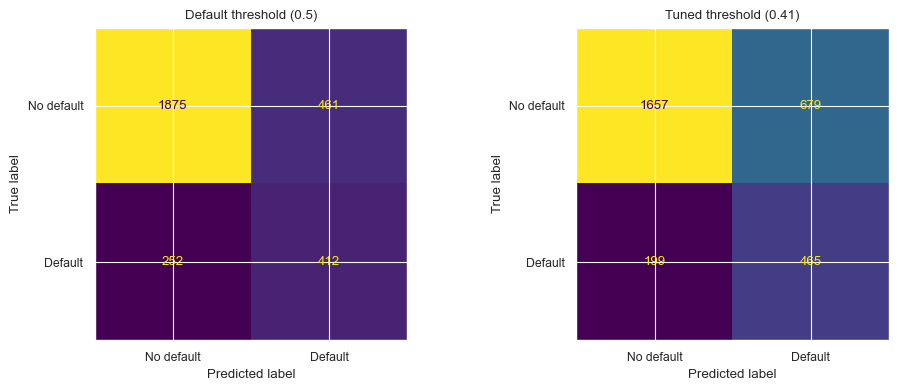

In [71]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, threshold, title in zip(
    axes,
    [0.5, 0.41],
    ['Default threshold (0.5)', f'Tuned threshold ({0.41})']
):
    preds_t = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_val_fe, preds_t)
    ConfusionMatrixDisplay(cm, display_labels=['No default','Default']).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [72]:
import json

In [73]:
# chosen threshold = 0.41. at this threshold precision is 40% and recall is 70%
threshold = 0.41
preds_t = (probs >= threshold).astype(int)
overall_metrics["uncalibrated_model"] = {"auc_score":auc,
                                         "threshold_used":threshold,
                                         "recall": recall_score(y_true=y_val_fe, y_pred=preds_t),
                                         "precision": precision_score(y_true=y_val_fe, y_pred=preds_t),
                                         "f1": f1_score(y_true=y_val_fe, y_pred=preds_t)}
print(json.dumps(overall_metrics, indent=4))

{
    "uncalibrated_model": {
        "auc_score": 0.7853812510315233,
        "threshold_used": 0.41,
        "recall": 0.7003012048192772,
        "precision": 0.40646853146853146,
        "f1": 0.5143805309734514
    }
}


In [74]:
# chosen threshold for raw probs
def assign_decision(prob):
    if prob<0.35:
        return "APPROVE"
    elif prob>=0.7:
        return "REJECT"
    else:
        return "REVIEW"
    

In [75]:
df_eval = val_df_fe.copy()
df_eval['raw_probs'] = probs
df_eval['dec_raw_probs'] = df_eval['raw_probs'].apply(assign_decision)
df_eval[["target", "raw_probs", "dec_raw_probs"]].head(10)

,target,raw_probs,dec_raw_probs
26487,0,0.360395,REVIEW
23307,1,0.198625,APPROVE
4018,1,0.643076,REVIEW
22514,0,0.295721,APPROVE
29029,0,0.222523,APPROVE
6319,0,0.298457,APPROVE
1664,0,0.246181,APPROVE
5693,0,0.415667,REVIEW
6236,0,0.365372,REVIEW
15702,0,0.288223,APPROVE


### **CALIBRATION**

In [76]:
from sklearn.calibration import CalibratedClassifierCV

In [77]:
calibrated_model = CalibratedClassifierCV(estimator=models_feature_eng['Random Forest'], 
                                          method='isotonic', 
                                          cv=5)
calibrated_model.fit(X_train_fe, y_train_fe)

,estimator,RandomForestC...ndom_state=42)
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,n_estimators,50
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [78]:
calibrated_probs = calibrated_model.predict_proba(X_val_fe)[:,1]
auc_cal = roc_auc_score(y_val_fe, calibrated_probs)
print(f"CALIBRATED MODEL AUC SCORE: {auc_cal}")

CALIBRATED MODEL AUC SCORE: 0.7888458800957254


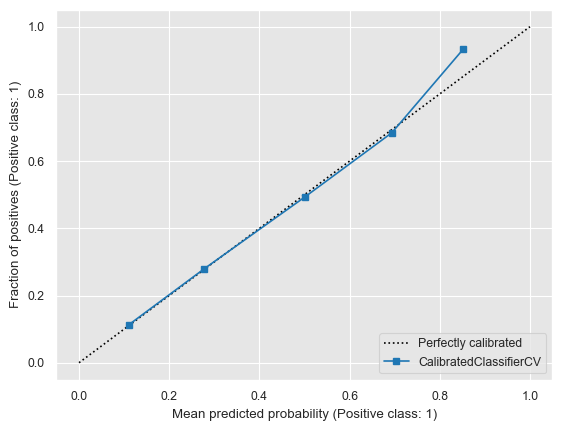

In [79]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    calibrated_model,
    X_val_fe,
    y_val_fe
)
plt.show()

In [80]:
thresholds_to_try = np.arange(0.1, 0.9, 0.01)
cal_scores = []

for t in thresholds_to_try:
    preds_cal = (calibrated_probs >= t).astype(int)
    cal_scores.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_val_fe, preds_cal, zero_division=0),
        'recall':    recall_score(y_val_fe, preds_cal),
        'f1':        f1_score(y_val_fe, preds_cal)
    })

cal_scores_df = pd.DataFrame(cal_scores)

# best by F1
best_f1_row = cal_scores_df.loc[cal_scores_df['f1'].idxmax()]
print(best_f1_row)

# best recall while keeping precision above 0.50
viable = cal_scores_df[cal_scores_df['precision'] >= 0.4]
best_recall_row = viable.loc[viable['recall'].idxmax()]
print(best_recall_row)

threshold    0.310000
precision    0.576299
recall       0.534639
f1           0.554688
Name: 21, dtype: float64
threshold    0.180000
precision    0.412600
recall       0.700301
f1           0.519263
Name: 8, dtype: float64


In [81]:
cal_scores_df.head(60)

,threshold,precision,recall,f1
0,0.10,0.286309,0.932229,0.438075
1,0.11,0.295257,0.918675,0.446886
2,0.12,0.309412,0.896084,0.459992
3,0.13,0.322707,0.868976,0.470636
4,0.14,0.342303,0.823795,0.483643
5,0.15,0.358178,0.781627,0.491245
6,0.16,0.376133,0.750000,0.501006
7,0.17,0.390851,0.733434,0.509948
8,0.18,0.412600,0.700301,0.519263
9,0.19,0.427083,0.679217,0.524419


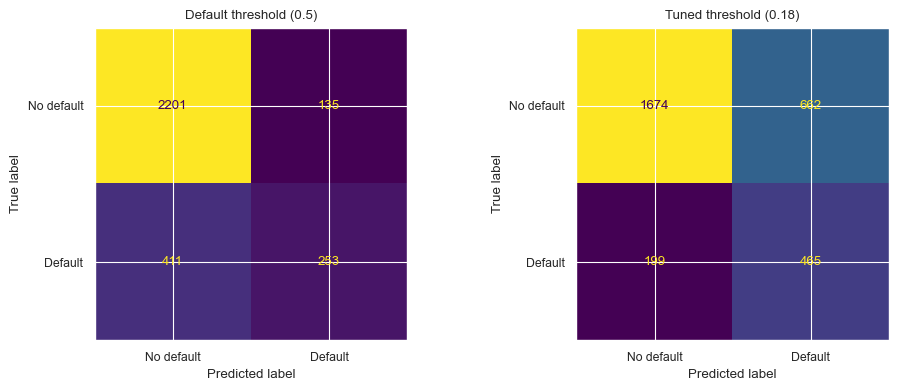

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, threshold, title in zip(
    axes,
    [0.5, 0.18],
    ['Default threshold (0.5)', f'Tuned threshold ({0.18})']
):
    #preds_t = (probs >= threshold).astype(int)
    preds_cal = (calibrated_probs >= threshold).astype(int)
    cm = confusion_matrix(y_val_fe, preds_cal)
    ConfusionMatrixDisplay(cm, display_labels=['No default','Default']).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [83]:
df_eval['cal_prob'] = calibrated_probs
df_eval[["target", "raw_probs", "dec_raw_probs", "cal_prob"]].head(10)

,target,raw_probs,dec_raw_probs,cal_prob
26487,0,0.360395,REVIEW,0.164724
23307,1,0.198625,APPROVE,0.037093
4018,1,0.643076,REVIEW,0.362254
22514,0,0.295721,APPROVE,0.117117
29029,0,0.222523,APPROVE,0.075719
6319,0,0.298457,APPROVE,0.119386
1664,0,0.246181,APPROVE,0.061949
5693,0,0.415667,REVIEW,0.194904
6236,0,0.365372,REVIEW,0.139436
15702,0,0.288223,APPROVE,0.091249


In [84]:
# chosen threshold = 0.18.
threshold_c = 0.18
preds_c = (calibrated_probs >= threshold_c).astype(int)
overall_metrics["calibrated_model"] = {"auc_score":auc_cal,
                                       "threshold_c":threshold_c,
                                         "recall": recall_score(y_true=y_val_fe, y_pred=preds_c),
                                         "precision": precision_score(y_true=y_val_fe, y_pred=preds_c),
                                         "f1": f1_score(y_true=y_val_fe, y_pred=preds_c)}
print(json.dumps(overall_metrics, indent=4))


{
    "uncalibrated_model": {
        "auc_score": 0.7853812510315233,
        "threshold_used": 0.41,
        "recall": 0.7003012048192772,
        "precision": 0.40646853146853146,
        "f1": 0.5143805309734514
    },
    "calibrated_model": {
        "auc_score": 0.7888458800957254,
        "threshold_c": 0.18,
        "recall": 0.7003012048192772,
        "precision": 0.4125998225377107,
        "f1": 0.5192629815745393
    }
}


In [85]:
def loan_decision(prob, lower_threshold=0.12, upper_threshold=0.30):

    # 12% just to give an allowance
    if prob < lower_threshold:
        return "APPROVE"

    elif prob >= upper_threshold:
        return "REJECT"

    else:
        return "REVIEW"

In [86]:
df_eval['cal_decision'] = df_eval['cal_prob'].apply(loan_decision)
df_eval[["target", "raw_probs", "dec_raw_probs", "cal_prob", "cal_decision"]].head(10)

,target,raw_probs,dec_raw_probs,cal_prob,cal_decision
26487,0,0.360395,REVIEW,0.164724,REVIEW
23307,1,0.198625,APPROVE,0.037093,APPROVE
4018,1,0.643076,REVIEW,0.362254,REJECT
22514,0,0.295721,APPROVE,0.117117,APPROVE
29029,0,0.222523,APPROVE,0.075719,APPROVE
6319,0,0.298457,APPROVE,0.119386,APPROVE
1664,0,0.246181,APPROVE,0.061949,APPROVE
5693,0,0.415667,REVIEW,0.194904,REVIEW
6236,0,0.365372,REVIEW,0.139436,REVIEW
15702,0,0.288223,APPROVE,0.091249,APPROVE


#### **EVALUATE RAW vs CALIBRATED DECISIONS**

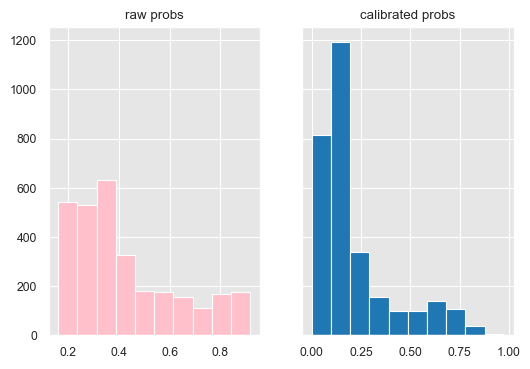

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
axes[0].hist(df_eval['raw_probs'], color='pink')
axes[0].set_title("raw probs")
axes[1].hist(df_eval['cal_prob'])
axes[1].set_title("calibrated probs")
plt.show()

In [88]:
# how many actual DEFAULTS did we REJECT
# how many actual DEFAULTS did we APPROVE
# how many actual DEFAULTS did we REVIEW

# how many actual NON-DEFAULTS did we REJECT
# how many actual NON-DEFAULTS did we APPROVE
# how many actual NON-DEFAULTS did we REVIEW

## **BUSINESS VIEW vs TESTING THRESHOLDS**

In [89]:
# Trying different thresholds
def business_function(df, lower_threshold, upper_threshold):
    def loan_decision(prob):
      # 12% just to give an allowance
      if prob < lower_threshold:
            return "APPROVE"
      elif prob >= upper_threshold:
            return "REJECT"
      else:
            return "REVIEW"
      
    df_copy = df.copy()
    df_copy['decision'] = df_copy['cal_probs'].apply(loan_decision)
    #print(f"Distribution using lower threshold of {lower_threshold} and upper threshold of {upper_threshold}:\n \
     #     {df_copy['decision'].value_counts()}")

    # create features to evaluate the loss if someone defaults
    df_copy['total_bill_amt'] = df_copy[['bill_amt_mth_6', "bill_amt_mth_5", "bill_amt_mth_4", 
                                                 "bill_amt_mth_3", "bill_amt_mth_2", "bill_amt_mth_1"]].sum(axis=1)

    # missed_exposure
    missed_exposure = df_copy[(df_copy['target']==0)&(df_copy['decision']=="REJECT")]['total_bill_amt'].sum()
     
    # default_exposure
    default_exposure = df_copy[(df_copy['target']==1)&(df_copy['decision']=="APPROVE")]['total_bill_amt'].sum()

    # missed exposure to default exposure
    exposure_ratio = missed_exposure/default_exposure

    # review rate
    reviews = df_copy[df_copy['decision']=="REVIEW"]
    review_rate = len(reviews)/df_copy.shape[0]

    # approval default rate
    approval_default_rate = df_copy[df_copy['decision']=="APPROVE"]['target'].mean()

    # approval rate
    approvals = df_copy[df_copy['decision']=="APPROVE"].shape[0]
    approval_rate = approvals/len(df_copy)

    # rejection rate
    rejections = df_copy[df_copy['decision']=="REJECT"].shape[0]
    rejection_rate = rejections/len(df_copy)

    # approve count
    approve_count = (df_copy['decision']=="APPROVE").sum()

    # reject count
    reject_count = (df_copy['decision']=="REJECT").sum()

    # review count
    review_count = (df_copy['decision']=="REVIEW").sum()


    metrics = {"thres":(lower_threshold, upper_threshold),
               "missed_exp":missed_exposure,
               "def_exp": default_exposure,
               "exp_ratio":exposure_ratio,
               "app_cnt":approve_count,
               "rej_cnt": reject_count,
               "rev_cnt": review_count,
               "appr_def_rate":round(approval_default_rate, 4),
               "rev_rate":round(review_rate, 4),
               "appr_rate": round(approval_rate, 4),
               "rej_rate": round(rejection_rate, 4)
               }
      
    return metrics                                      

In [90]:
list_of_threshold = [

    # tighter approval, moderate rejection
    (0.08, 0.25),
    (0.10, 0.25),
    (0.12, 0.25),

    # balanced operational region
    (0.10, 0.30),
    (0.12, 0.30),
    (0.15, 0.30),
    (0.18, 0.30),

    # wider review band
    (0.10, 0.40),
    (0.12, 0.40),
    (0.15, 0.40),
    (0.18, 0.40),

    # conservative rejection policy
    (0.10, 0.50),
    (0.12, 0.50),
    (0.15, 0.50),
    (0.18, 0.50),
    (0.20, 0.50),

    # aggressive approval policy
    (0.20, 0.35),
    (0.22, 0.35),

    # aggressive rejection policy
    (0.08, 0.20),
    (0.10, 0.20)

]

In [91]:
business_df = val_df_fe.copy()
business_df['cal_probs'] = calibrated_probs
all_metrics = []
for low, high in list_of_threshold:
    metrics = business_function(business_df, lower_threshold=low, upper_threshold=high)
    all_metrics.append(metrics)
all_metrics_df = pd.DataFrame(all_metrics) 
all_metrics_df

,thres,missed_exp,def_exp,exp_ratio,app_cnt,rej_cnt,rev_cnt,appr_def_rate,rev_rate,appr_rate,rej_rate
0,"(0.08, 0.25)",86599097,13204728,6.558189,638,783,1579,0.0517,0.5263,0.2127,0.2610
1,"(0.1, 0.25)",86599097,17264819,5.015928,838,783,1379,0.0537,0.4597,0.2793,0.2610
2,"(0.12, 0.25)",86599097,26728424,3.239963,1077,783,1140,0.0641,0.3800,0.3590,0.2610
3,"(0.1, 0.3)",67456603,17264819,3.907171,838,632,1530,0.0537,0.5100,0.2793,0.2107
4,"(0.12, 0.3)",67456603,26728424,2.523778,1077,632,1291,0.0641,0.4303,0.3590,0.2107
5,"(0.15, 0.3)",67456603,43121893,1.564324,1551,632,817,0.0935,0.2723,0.5170,0.2107
6,"(0.18, 0.3)",67456603,53082998,1.270776,1873,632,495,0.1062,0.1650,0.6243,0.2107
7,"(0.1, 0.4)",49936897,17264819,2.892408,838,483,1679,0.0537,0.5597,0.2793,0.1610
8,"(0.12, 0.4)",49936897,26728424,1.868307,1077,483,1440,0.0641,0.4800,0.3590,0.1610
9,"(0.15, 0.4)",49936897,43121893,1.158040,1551,483,966,0.0935,0.3220,0.5170,0.1610


In [92]:
# sampled thresholds
all_metrics_df.iloc[[4,11,16]]

,thres,missed_exp,def_exp,exp_ratio,app_cnt,rej_cnt,rev_cnt,appr_def_rate,rev_rate,appr_rate,rej_rate
4,"(0.12, 0.3)",67456603,26728424,2.523778,1077,632,1291,0.0641,0.4303,0.3590,0.2107
11,"(0.1, 0.5)",40100187,17264819,2.322653,838,388,1774,0.0537,0.5913,0.2793,0.1293
16,"(0.2, 0.35)",59554407,54463788,1.093468,2024,563,413,0.1126,0.1377,0.6747,0.1877


In [93]:
def_rate_val_set = round(business_df['target'].mean(),4)*100
print(f"Default rate of Validation dataset is {def_rate_val_set}% which is more than twice the \n" 
"highest approval default rate (11.78%) using the thresholds above. Technically, any of the thresholds \n"  
"could be used since each captures has a better default rate that the val_dataset default rate. \n"
"The thresholds shows tradeoffs between exposures, counts and rates between approvals, reviews, and rejections. \n\n"
"The choice now has to be 'which threshold optimizes the business goal?' \n"
"For instance, for the sampled thresholds above: \n\n"
"A. threshold(0.2, 0.35): has the lowest operational workload (measured by review rate-13.77%) but the highest approval \n"
"default rate (11.26%) signalling that customers who are likely to default are approved by this threshold than \n"
"other thresholds. \n"
"B. threshold(0.1, 0.5): is in contrast to threshold A because it has the lowest approval default rate (5.37%) but \n"
"a very high review rate (59.13%) which impacts operational workload significantly. \n "
"C. threshold (0.12, 0.3): shows a balance between threshold A and B, with approval default rate of 6.41% and \n"
"43.03% of customer applications being reviewed before approval or rejection. \n\n"
"The chosen threshold for the rest of the analysis will be (0.12, 0.3) due to its balance."
)


Default rate of Validation dataset is 22.13% which is more than twice the 
highest approval default rate (11.78%) using the thresholds above. Technically, any of the thresholds 
could be used since each captures has a better default rate that the val_dataset default rate. 
The thresholds shows tradeoffs between exposures, counts and rates between approvals, reviews, and rejections. 

The choice now has to be 'which threshold optimizes the business goal?' 
For instance, for the sampled thresholds above: 

A. threshold(0.2, 0.35): has the lowest operational workload (measured by review rate-13.77%) but the highest approval 
default rate (11.26%) signalling that customers who are likely to default are approved by this threshold than 
other thresholds. 
B. threshold(0.1, 0.5): is in contrast to threshold A because it has the lowest approval default rate (5.37%) but 
a very high review rate (59.13%) which impacts operational workload significantly. 
 C. threshold (0.12, 0.3): shows a balanc

# **FURTHER ANALYSIS**

In [94]:
print("How cases will fare:")
df_eval['cal_decision'].value_counts()

How cases will fare:


cal_decision
REVIEW     1291
APPROVE    1077
REJECT      632
Name: count, dtype: int64

#### **DISTRIBUTION OF ALL CASES**



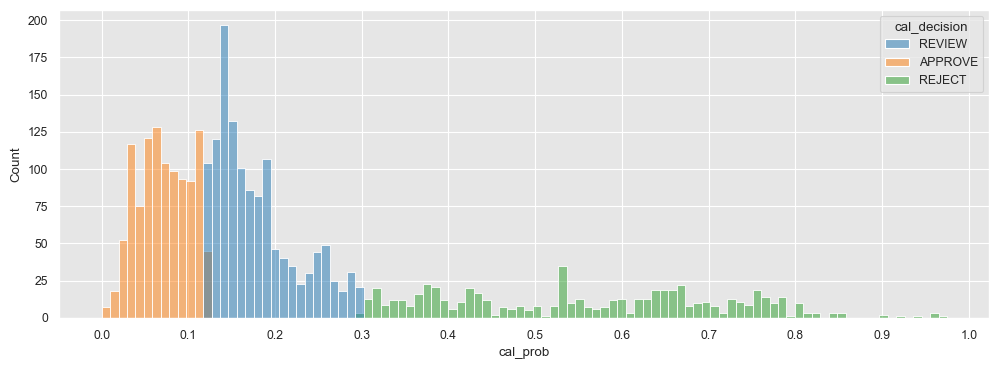

In [95]:
plt.figure(figsize=(12,4))
x_ticks = np.arange(0, 1.1, 0.1)
g = sns.histplot(data = df_eval, x = 'cal_prob', hue='cal_decision', bins=100)
g.set_xticks(x_ticks)
plt.show()

> Using a lower threshold of 0.12 and higher threshold of 0.3: 


*1. There will be 1291 cases that would be reviewed.*


*2. There will be 632 rejected cases.*


*3. 1077 customers will be approved*

#### **1. AMONG THOSE APPROVED, WHAT IS THE DEFAULT RATE?**

In [96]:
# approval default rate
approval_default_rate = df_eval[df_eval['cal_decision']=="APPROVE"]['target'].mean()
print(f"APPROVAL DEFAULT RATE: {round(approval_default_rate, 4)*100}%")

APPROVAL DEFAULT RATE: 6.41%


In [97]:
# defaults that were approved
defaults_approved = df_eval[(df_eval['cal_decision']=="APPROVE") & (df_eval['target']==1)]

# summary statistics of calibrated probabilities
print("SUMMARY STATS (CALIBRATED PROBS) OF DEFAULTS THAT WERE WRONGLY APPROVED USING THRESHOLD")
defaults_approved['cal_prob'].describe()

SUMMARY STATS (CALIBRATED PROBS) OF DEFAULTS THAT WERE WRONGLY APPROVED USING THRESHOLD


count    69.000000
mean      0.082800
std       0.026239
min       0.028847
25%       0.061949
50%       0.081760
75%       0.107806
max       0.118843
Name: cal_prob, dtype: float64

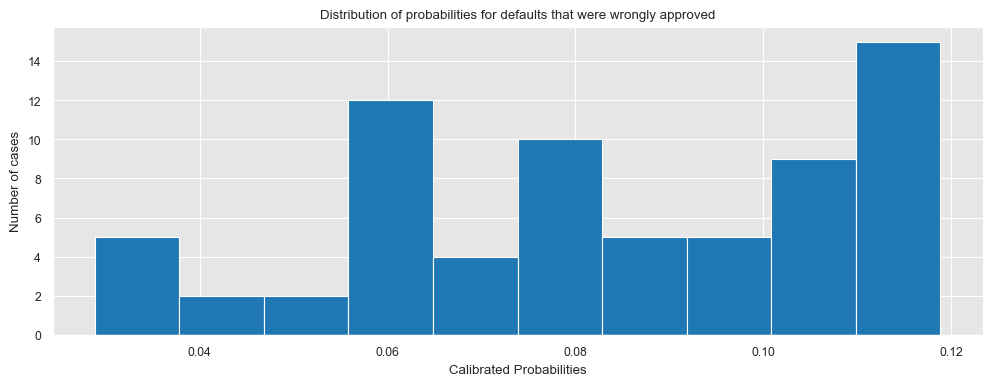

In [98]:
plt.figure(figsize=(12,4))
plt.hist(defaults_approved['cal_prob'])
plt.ylabel("Number of cases")
plt.xlabel("Calibrated Probabilities")
plt.title("Distribution of probabilities for defaults that were wrongly approved")
plt.show()

In [99]:
defaults_approved.describe().T

,count,mean,std,min,25%,50%,75%,max
limit,69.0,200724.637681,110497.788647,50000.000000,110000.000000,180000.000000,270000.000000,500000.000000
gender,69.0,1.739130,0.442326,1.000000,1.000000,2.000000,2.000000,2.000000
edu,69.0,1.913043,0.701660,1.000000,1.000000,2.000000,2.000000,4.000000
marital_status,69.0,1.492754,0.532010,1.000000,1.000000,1.000000,2.000000,3.000000
age,69.0,35.507246,9.193385,23.000000,29.000000,33.000000,41.000000,70.000000
rep_status_mth_6,69.0,-0.289855,0.644010,-2.000000,0.000000,0.000000,0.000000,1.000000
rep_status_mth_5,69.0,-0.333333,0.634004,-2.000000,0.000000,0.000000,0.000000,0.000000
rep_status_mth_4,69.0,-0.246377,0.553220,-2.000000,0.000000,0.000000,0.000000,0.000000
rep_status_mth_3,69.0,-0.260870,0.559731,-2.000000,0.000000,0.000000,0.000000,0.000000
rep_status_mth_2,69.0,-0.304348,0.601575,-2.000000,0.000000,0.000000,0.000000,0.000000


#### **2. AMONG ALL REJECTS, WHAT IS THE % RIGHTFULLY REJECTED?**

In [100]:
# 
default_rejected = df_eval[df_eval['cal_decision']=="REJECT"]['target'].mean()
print(f"DEFAULT RATE AMONG THOSE REJECTED: {round(default_rejected, 4)*100}%")

DEFAULT RATE AMONG THOSE REJECTED: 56.8%


In [101]:
# defaults that were approved
defaults_rejected = df_eval[(df_eval['cal_decision']=="REJECT") & (df_eval['target']==1)]

# summary statistics of calibrated probabilities
# the expectation was that for DEFAULTS, they would have high probabilities but in this case probs they were low
print("SUMMARY STATS (CALIBRATED PROBS) OF DEFAULTS THAT WERE WRONGLY APPROVED USING THRESHOLD")
defaults_rejected['cal_prob'].describe()

SUMMARY STATS (CALIBRATED PROBS) OF DEFAULTS THAT WERE WRONGLY APPROVED USING THRESHOLD


count    359.000000
mean       0.594641
std        0.158227
min        0.307164
25%        0.441985
50%        0.623064
75%        0.720127
max        0.975000
Name: cal_prob, dtype: float64

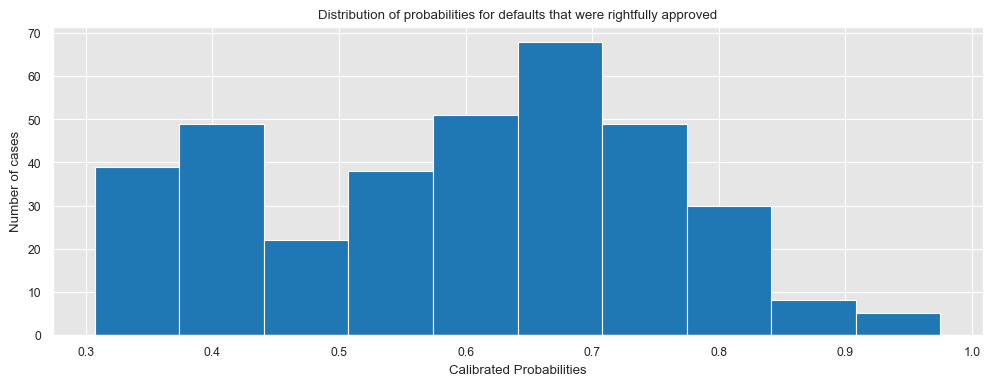

In [102]:
plt.figure(figsize=(12,4))
plt.hist(defaults_rejected['cal_prob'])
plt.ylabel("Number of cases")
plt.xlabel("Calibrated Probabilities")
plt.title("Distribution of probabilities for defaults that were rightfully approved")
plt.show()

In [103]:
# summary statistics
defaults_rejected.describe().T

,count,mean,std,min,25%,50%,75%,max
limit,359.0,113175.487465,109882.872434,10000.000000,30000.000000,80000.000000,150000.000000,600000.000000
gender,359.0,1.576602,0.494787,1.000000,1.000000,2.000000,2.000000,2.000000
edu,359.0,1.910864,0.662540,1.000000,1.000000,2.000000,2.000000,3.000000
marital_status,359.0,1.506964,0.511686,1.000000,1.000000,2.000000,2.000000,3.000000
age,359.0,35.520891,9.881362,21.000000,27.000000,34.000000,42.000000,73.000000
rep_status_mth_6,359.0,1.562674,1.083574,-1.000000,1.000000,2.000000,2.000000,8.000000
rep_status_mth_5,359.0,1.289694,1.374012,-2.000000,0.000000,2.000000,2.000000,7.000000
rep_status_mth_4,359.0,1.116992,1.467608,-2.000000,0.000000,2.000000,2.000000,7.000000
rep_status_mth_3,359.0,1.019499,1.705122,-2.000000,0.000000,2.000000,2.000000,7.000000
rep_status_mth_2,359.0,0.924791,1.705208,-2.000000,0.000000,0.000000,2.000000,7.000000


In [104]:
df_eval[df_eval['target']==1][["rep_status_mth_6", "rep_status_mth_5", "rep_status_mth_4",
"rep_status_mth_3", "rep_status_mth_2", "rep_status_mth_1"]].describe().T

,count,mean,std,min,25%,50%,75%,max
rep_status_mth_6,664.0,0.661145,1.378983,-2.0,0.00,1.0,2.0,8.0
rep_status_mth_5,664.0,0.460843,1.473231,-2.0,0.00,0.0,2.0,7.0
rep_status_mth_4,664.0,0.367470,1.490208,-2.0,-0.25,0.0,2.0,7.0
rep_status_mth_3,664.0,0.311747,1.601502,-2.0,-1.00,0.0,2.0,7.0
rep_status_mth_2,664.0,0.239458,1.571295,-2.0,-1.00,0.0,2.0,7.0
rep_status_mth_1,664.0,0.144578,1.551587,-2.0,-1.00,0.0,0.0,7.0


In [105]:
df_eval[df_eval['target']==1].groupby('cal_decision')[["rep_status_mth_6", "rep_status_mth_5", "rep_status_mth_4",
"rep_status_mth_3", "rep_status_mth_2", "rep_status_mth_1", "pay_streak", "avg_payment_delay",
"utilization_rate", "pmt_ratio", "bill_trend", "avg_utilization", "worst_pmt_delay"]].mean()

,rep_status_mth_6,rep_status_mth_5,rep_status_mth_4,rep_status_mth_3,rep_status_mth_2,rep_status_mth_1,pay_streak,avg_payment_delay,utilization_rate,pmt_ratio,bill_trend,avg_utilization,worst_pmt_delay
cal_decision,,,,,,,,,,,,,
APPROVE,-0.289855,-0.333333,-0.246377,-0.260870,-0.304348,-0.304348,0.014493,-0.289855,0.449138,-6.177083,19733.347826,0.379588,-0.130435
REJECT,1.562674,1.289694,1.116992,1.019499,0.924791,0.771588,3.534819,1.114206,0.554727,-0.997211,9021.933148,0.538034,2.345404
REVIEW,-0.432203,-0.567797,-0.593220,-0.597458,-0.644068,-0.677966,0.317797,-0.585452,0.337940,0.247196,8422.826271,0.305197,0.088983


> Cases that were actual DEFAULTS and REJECTED by the system have higher mean for the repayment variables.

> Cases that were actual DEFAULTS and APPROVED by the system have the lowest mean and max values for repayment variables. Maybe model could not learn other nuances about these examples.

#### **3. REVIEW RATE**

In [106]:
reviews = df_eval[df_eval['cal_decision']=="REVIEW"]['target']
review_rate = len(reviews)/df_eval.shape[0]
default_rate_in_reviews = reviews.mean()
print(f"Review rate: {round(review_rate, 4)*100}%")
print(f"Default rate in reviews: {round(default_rate_in_reviews, 2)*100}%")

Review rate: 43.03%
Default rate in reviews: 18.0%


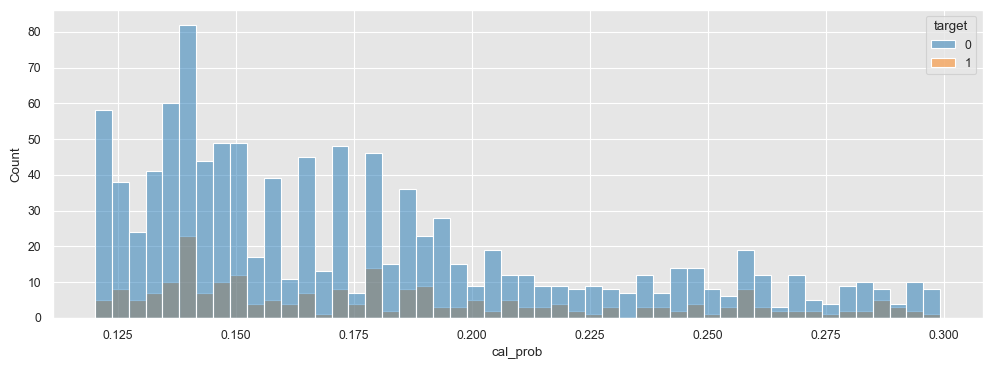

Aside the number of probs. being higher when prob. is lower, there is no signifanct pattern perculiar to a target


In [107]:
# reviews only set
reviews_df = df_eval[df_eval['cal_decision']=="REVIEW"]

plt.figure(figsize=(12,4))
#x_ticks = np.arange(0, 1.1, 0.1)
g = sns.histplot(data = reviews_df, x = 'cal_prob', hue='target', bins=50)
#g.set_xticks(x_ticks)
plt.show()
print("Aside the number of probs. being higher when prob. is lower, there is no signifanct pattern perculiar to " \
"a target")

## **TEST SET**

In [119]:
def loan_decision(prob, lower_threshold=0.12, upper_threshold=0.30):

    # 12% just to give an allowance
    if prob < lower_threshold:
        return "APPROVE"

    elif prob >= upper_threshold:
        return "REJECT"

    else:
        return "REVIEW"

In [156]:
test_df_fe_copy = test_df_fe.copy()

cal_test_probs = calibrated_model.predict_proba(X_test_fe)[:,1]
test_df_fe_copy['probability'] = cal_test_probs
test_df_fe_copy['prediction_raw'] = calibrated_model.predict(X_test_fe)
test_df_fe_copy['prediction_thres'] = (test_df_fe_copy['probability']>=0.3).astype(int)
test_df_fe_copy['decision'] = test_df_fe_copy['probability'].apply(loan_decision)
test_df_fe_copy.head(5)

,limit,gender,edu,marital_status,age,rep_status_mth_6,rep_status_mth_5,rep_status_mth_4,rep_status_mth_3,rep_status_mth_2,...,avg_payment_delay,utilization_rate,pmt_ratio,bill_trend,avg_utilization,worst_pmt_delay,probability,prediction_raw,prediction_thres,decision
11812,80000,2,2,1,37,-2,-2,-2,-2,-2,...,-2.000000,0.016550,0.820997,81,0.022702,-2,0.139436,0,0,REVIEW
9479,360000,2,1,1,32,1,-2,-2,-2,-2,...,-1.500000,0.000000,0.000000,0,0.000000,1,0.343037,0,1,REJECT
9117,360000,2,1,2,30,0,0,0,0,0,...,0.000000,0.112539,0.044429,29714,0.068741,0,0.061949,0,0,APPROVE
13779,50000,1,2,1,47,-2,-2,-2,-2,-2,...,-2.000000,-0.052800,-1.000000,-7342,0.019007,-2,0.131306,0,0,REVIEW
21046,230000,1,2,1,34,1,-2,-1,2,2,...,0.333333,0.000000,0.000000,-1133,0.000893,2,0.328467,0,1,REJECT


In [157]:
test_df_fe_copy['decision'].value_counts()

decision
REVIEW     1336
APPROVE    1047
REJECT      617
Name: count, dtype: int64

In [176]:
test_df_fe_copy['probability'].describe()

count    3000.000000
mean        0.222893
std         0.198215
min         0.000000
25%         0.093275
50%         0.146731
75%         0.262378
max         0.961667
Name: probability, dtype: float64

In [158]:
test_set_approval_def_rate = test_df_fe_copy[test_df_fe_copy['decision']=="APPROVE"]['target'].mean()
print(f"Test set approval default rate: {round(test_set_approval_def_rate, 4)*100}%")

Test set approval default rate: 8.6%


In [162]:
print("using default threshold or 0.5")
test_metrics = {"roc_auc_score": round(roc_auc_score(y_test_fe, cal_test_probs), 4),
                    "recall": round(recall_score(y_test_fe, test_df_fe_copy['prediction_raw']), 4), 
                    "precision": round(precision_score(y_test_fe, test_df_fe_copy['prediction_raw']), 4),
                    "f1_score": round(f1_score(y_test_fe, test_df_fe_copy['prediction_raw']), 4)
                    }
print(json.dumps(test_metrics, indent=4))

using default threshold or 0.5
{
    "roc_auc_score": 0.7654,
    "recall": 0.3741,
    "precision": 0.62,
    "f1_score": 0.4666
}


In [163]:
print("using threshold or 0.3")
test_metrics_thres = {"roc_auc_score": round(roc_auc_score(y_test_fe, cal_test_probs), 4),
                    "recall": round(recall_score(y_test_fe, test_df_fe_copy['prediction_thres']), 4), 
                    "precision": round(precision_score(y_test_fe, test_df_fe_copy['prediction_thres']), 4),
                    "f1_score": round(f1_score(y_test_fe, test_df_fe_copy['prediction_thres']), 4)
                    }
print(json.dumps(test_metrics_thres, indent=4))

using threshold or 0.3
{
    "roc_auc_score": 0.7654,
    "recall": 0.5008,
    "precision": 0.5381,
    "f1_score": 0.5188
}


## **SHAP ANALYSIS**

In [117]:
import shap
shap.initjs()

In [118]:
explainer = shap.TreeExplainer(models_feature_eng['Random Forest'])
shap_values = explainer.shap_values(X_test_fe)

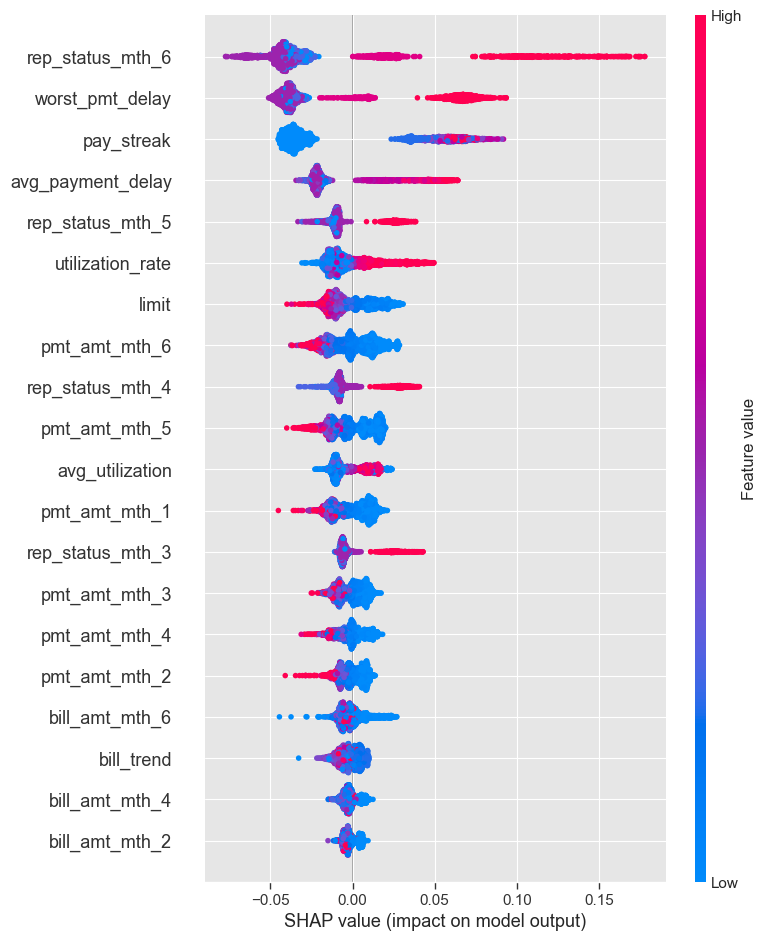

In [119]:
shap.summary_plot(shap_values[:,:,1], X_test_fe)

In [120]:
shap.force_plot(explainer.expected_value[1], shap_values[:,:,1][2], X_test_fe.iloc[2])

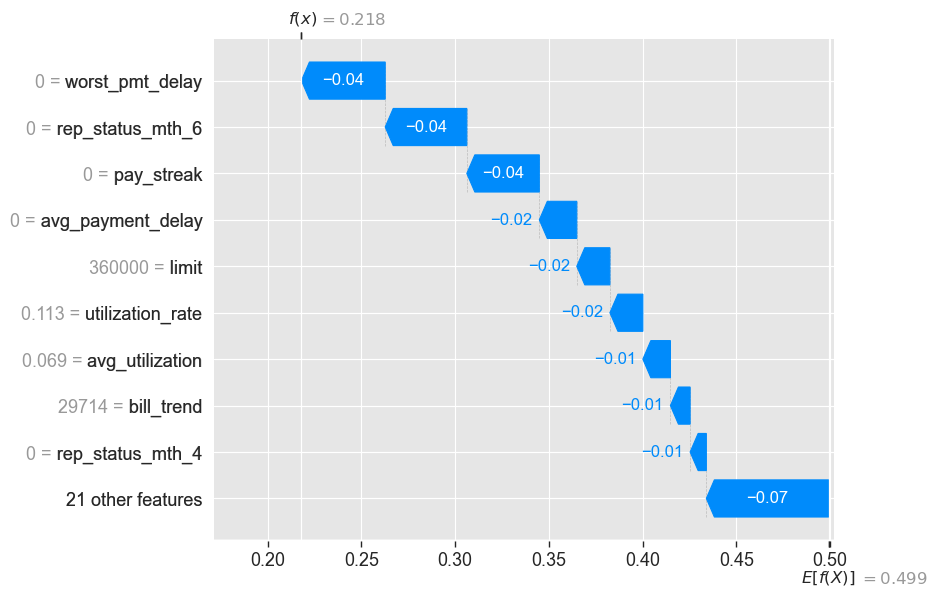

In [121]:
shap.waterfall_plot(shap.Explanation(values=shap_values[:,:,1][2], 
                                     base_values=explainer.expected_value[1],
                                     data=X_test_fe.iloc[2]))